# Model Development - Customer Churn Prediction
This notebook develops and compares different machine learning models for customer churn prediction.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from datetime import datetime
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('../src')

from data.data_loader import DataLoader
from data.preprocessor import DataPreprocessor
from ml_models.trainer import ModelTrainer

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

## 1. Data Loading and Preprocessing

In [23]:
# Set up MLflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")
experiment_name = f"customer_churn_model_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
mlflow.set_experiment(experiment_name)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Current experiment:", mlflow.get_experiment_by_name("customer_churn_model_development_2"))

2025/08/08 18:11:41 INFO mlflow.tracking.fluent: Experiment with name 'customer_churn_model_20250808_181141' does not exist. Creating a new experiment.


MLflow tracking URI: http://127.0.0.1:5000
Current experiment: <Experiment: artifact_location='mlflow-artifacts:/284825959266626510', creation_time=1754417468019, experiment_id='284825959266626510', last_update_time=1754417477522, lifecycle_stage='deleted', name='customer_churn_model_development_2', tags={}>


In [24]:
# Load data
data_loader = DataLoader('../data/raw')
df = data_loader.load_training_data()

In [25]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
# Preprocess data
preprocessor = DataPreprocessor(is_synthetic=False)
df_processed = preprocessor.fit_transform(df)

print(f"Processed dataset shape: {df_processed.shape}")
print(f"New features created: {set(df_processed.columns) - set(df.columns)}")

# Save preprocessor for later use
preprocessor.save('../models/artifacts/preprocessor.pkl')
print("Preprocessor saved!")

Processed dataset shape: (7010, 23)
New features created: {'is_new_customer', 'charges_per_month', 'avg_monthly_charges'}
Preprocessor saved!


In [27]:
# Prepare features and target
feature_columns = df_processed.columns

X = df_processed.drop(columns=['Churn'])
y = df_processed['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {list(X.columns)}")

Features shape: (7010, 22)
Target shape: (7010,)
Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charges', 'charges_per_month', 'is_new_customer']


In [28]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nChurn rates:")
print(f"Train: {y_train.mean():.2%}")
print(f"Validation: {y_val.mean():.2%}")
print(f"Test: {y_test.mean():.2%}")

Training set: (4486, 22)
Validation set: (1122, 22)
Test set: (1402, 22)

Churn rates:
Train: 26.50%
Validation: 26.47%
Test: 26.46%


## 2. Baseline Models

In [29]:
# Define models to compare
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'HistGradient Boosting': HistGradientBoostingClassifier(max_iter=100, random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)  # verbose=0 wycisza output
}

# Store results
model_results = {}

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from mlflow.models.signature import infer_signature

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    with mlflow.start_run(run_name=f"baseline_{name.lower().replace(' ', '_')}"):
        # Log model parameters
        mlflow.log_params(model.get_params())

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        y_pred_test = model.predict(X_test)

        # Probabilities
        y_proba_train = model.predict_proba(X_train)[:, 1]
        y_proba_val = model.predict_proba(X_val)[:, 1]
        y_proba_test = model.predict_proba(X_test)[:, 1]
        
        signature = infer_signature(X_val, y_pred_val) 

        # Calculate metrics
        metrics = {
            'train_accuracy': accuracy_score(y_train, y_pred_train),
            'val_accuracy': accuracy_score(y_val, y_pred_val),
            'test_accuracy': accuracy_score(y_test, y_pred_test),
            'train_precision': precision_score(y_train, y_pred_train),
            'val_precision': precision_score(y_val, y_pred_val),
            'test_precision': precision_score(y_test, y_pred_test),
            'train_recall': recall_score(y_train, y_pred_train),
            'val_recall': recall_score(y_val, y_pred_val),
            'test_recall': recall_score(y_test, y_pred_test),
            'train_f1': f1_score(y_train, y_pred_train),
            'val_f1': f1_score(y_val, y_pred_val),
            'test_f1': f1_score(y_test, y_pred_test),
            'train_auc': roc_auc_score(y_train, y_proba_train),
            'val_auc': roc_auc_score(y_val, y_proba_val),
            'test_auc': roc_auc_score(y_test, y_proba_test)
        }

        # Log metrics
        mlflow.log_metrics(metrics)

        # Log model
        mlflow.sklearn.log_model(model, name=name, signature=signature, input_example=X_val.iloc[:5])

        # Store results
        model_results[name] = {
            'model': model,
            'metrics': metrics,
            'predictions': {
                'val_pred': y_pred_val,
                'val_proba': y_proba_val,
               'test_pred': y_pred_test,
               'test_proba': y_proba_test
           }
       }
    
        print(f"Validation Accuracy: {metrics['val_accuracy']:.4f}")
        print(f"Validation AUC: {metrics['val_auc']:.4f}")
        print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
        print(f"Test AUC: {metrics['test_auc']:.4f}")

print("\nBaseline models training completed!")


Training Random Forest...
Validation Accuracy: 0.7879
Validation AUC: 0.8299
Test Accuracy: 0.8031
Test AUC: 0.8363
🏃 View run baseline_random_forest at: http://127.0.0.1:5000/#/experiments/355494351460860678/runs/394add065b1c408f9524679629deb83c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/355494351460860678

Training Gradient Boosting...
Validation Accuracy: 0.8075
Validation AUC: 0.8493
Test Accuracy: 0.8039
Test AUC: 0.8462
🏃 View run baseline_gradient_boosting at: http://127.0.0.1:5000/#/experiments/355494351460860678/runs/4fdc8472e2de4da2948def45fd580b53
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/355494351460860678

Training HistGradient Boosting...
Validation Accuracy: 0.7861
Validation AUC: 0.8354
Test Accuracy: 0.7946
Test AUC: 0.8415
🏃 View run baseline_histgradient_boosting at: http://127.0.0.1:5000/#/experiments/355494351460860678/runs/09aba74b1417475b94cc2e44924e1ac9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/355494351460860678



## 3. Model Comparison

Model Comparison (Validation Set):
           Random Forest  Gradient Boosting  HistGradient Boosting  CatBoost
Accuracy          0.7879             0.8075                 0.7861    0.7977
Precision         0.6359             0.6800                 0.6154    0.6522
Recall            0.4646             0.5152                 0.5118    0.5051
F1                0.5370             0.5862                 0.5588    0.5693
Auc               0.8299             0.8493                 0.8354    0.8399


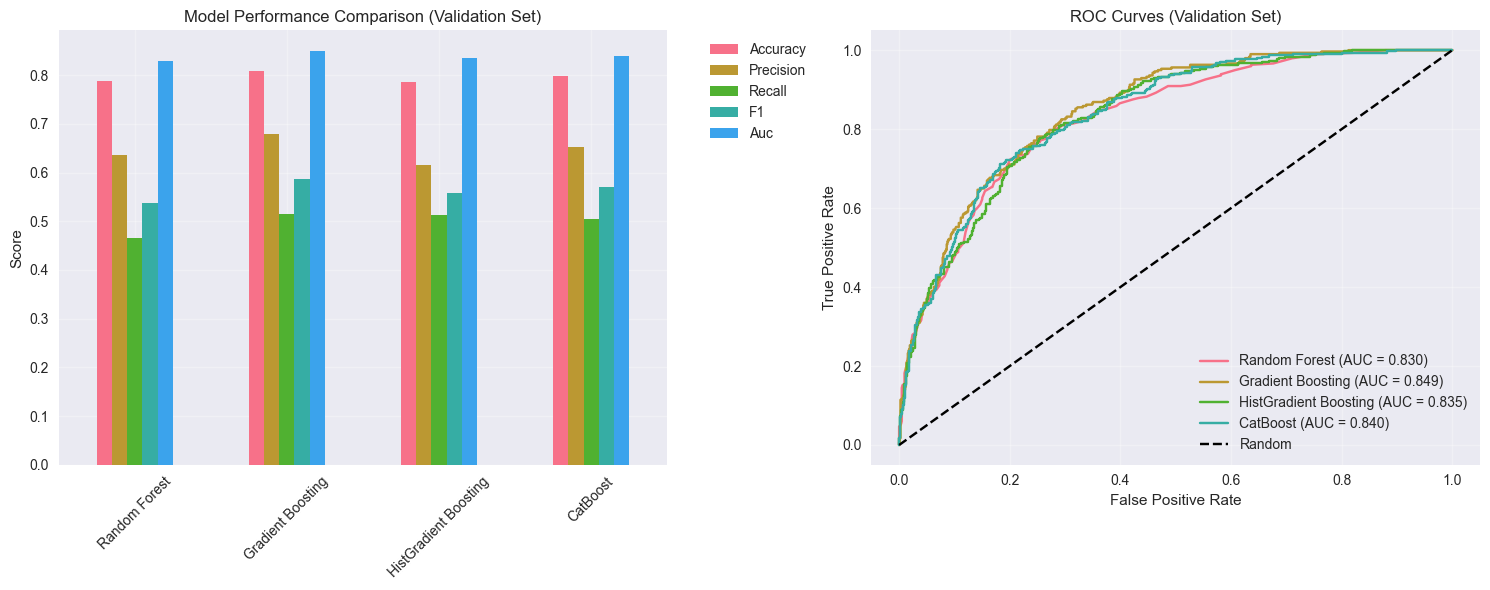


Best model: Gradient Boosting (AUC: 0.8493)


In [31]:
# Create comparison dataframe
comparison_metrics = ['val_accuracy', 'val_precision', 'val_recall', 'val_f1', 'val_auc']
comparison_df = pd.DataFrame({
    model_name: [model_results[model_name]['metrics'][metric] for metric in comparison_metrics]
    for model_name in model_results.keys()
}, index=[metric.replace('val_', '').title() for metric in comparison_metrics])

print("Model Comparison (Validation Set):")
print(comparison_df.round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot of validation metrics
comparison_df.T.plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Model Performance Comparison (Validation Set)')
axes[0].set_ylabel('Score')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# ROC curves
for model_name in model_results.keys():
    y_proba = model_results[model_name]['predictions']['val_proba']
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_score = model_results[model_name]['metrics']['val_auc']
    axes[1].plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (Validation Set)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best model
best_model_name = comparison_df.loc['Auc'].idxmax()
best_auc = comparison_df.loc['Auc'].max()
print(f"\nBest model: {best_model_name} (AUC: {best_auc:.4f})")

## 4. Hyperparameter Tuning

In [32]:
# Hyperparameter tuning for the best model
print(f"Performing hyperparameter tuning for {best_model_name}...")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 300],
        'max_depth': [3, 5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': ['balanced', None]
    }
    base_model = RandomForestClassifier(random_state=42)

elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 300],
        'learning_rate': [0.01, 0.1],
        'max_depth': [2, 4, 6, 8],
        'subsample': [0.5, 1.0],
        'min_samples_split': [2, 4, 6, 8]
    }
    base_model = GradientBoostingClassifier(random_state=42)

elif best_model_name == 'HistGradient Boosting':
    param_grid = {
        'learning_rate': [0.01, 0.05, 0.1],
        'max_iter': [100, 200, 300],
        'max_depth': [None, 5, 10, 20],
        'min_samples_leaf': [20, 50, 100],
        'l2_regularization': [0.0, 1.0, 10.0]
    }
    base_model = HistGradientBoostingClassifier(random_state=42)

elif best_model_name == 'CatBoost':
    param_grid = {
        'iterations': [100, 200],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5, 7]
    }
    base_model = CatBoostClassifier(verbose=0, random_state=42)

print(f"Parameter grid: {param_grid}")

Performing hyperparameter tuning for Gradient Boosting...
Parameter grid: {'n_estimators': [100, 300], 'learning_rate': [0.01, 0.1], 'max_depth': [2, 4, 6, 8], 'subsample': [0.5, 1.0], 'min_samples_split': [2, 4, 6, 8]}


In [33]:
# Perform grid search
with mlflow.start_run(run_name=f"tuned_{best_model_name.lower().replace(' ', '_')}"):
    grid_search = GridSearchCV(
        base_model, 
        param_grid, 
        cv = 5, 
        scoring = 'roc_auc', 
        n_jobs = -1, 
        verbose = 1
    )

    print("Starting grid search...")
    grid_search.fit(X_train, y_train)

    # Get best model
    best_tuned_model = grid_search.best_estimator_

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

    # Log best parameters
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("cv_auc_score", grid_search.best_score_)

    # Evaluate tuned model
    y_pred_val_tuned = best_tuned_model.predict(X_val)
    y_proba_val_tuned = best_tuned_model.predict_proba(X_val)[:, 1]
    y_pred_test_tuned = best_tuned_model.predict(X_test)
    y_proba_test_tuned = best_tuned_model.predict_proba(X_test)[:, 1]

    # Calculate metrics for tuned model
    tuned_metrics = {
        'val_accuracy': accuracy_score(y_val, y_pred_val_tuned),
        'val_precision': precision_score(y_val, y_pred_val_tuned),
        'val_recall': recall_score(y_val, y_pred_val_tuned),
        'val_f1': f1_score(y_val, y_pred_val_tuned),
        'val_auc': roc_auc_score(y_val, y_proba_val_tuned),
        'test_accuracy': accuracy_score(y_test, y_pred_test_tuned),
        'test_precision': precision_score(y_test, y_pred_test_tuned),
        'test_recall': recall_score(y_test, y_pred_test_tuned),
        'test_f1': f1_score(y_test, y_pred_test_tuned),
        'test_auc': roc_auc_score(y_test, y_proba_test_tuned)
    }

    # Log metrics
    mlflow.log_metrics(tuned_metrics)

    # Log model
    mlflow.sklearn.log_model(model, name=name, signature=signature, input_example=X_val.iloc[:5])

    print(f"\nTuned model performance:")
    print(f"Validation AUC: {tuned_metrics['val_auc']:.4f}")
    print(f"Test AUC: {tuned_metrics['test_auc']:.4f}")

    # Compare with baseline
    baseline_val_auc = model_results[best_model_name]['metrics']['val_auc']
    improvement = tuned_metrics['val_auc'] - baseline_val_auc
    print(f"\nImprovement over baseline: {improvement:+.4f} AUC points")

Starting grid search...
Fitting 5 folds for each of 128 candidates, totalling 640 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation score: 0.8443

Tuned model performance:
Validation AUC: 0.8507
Test AUC: 0.8468

Improvement over baseline: +0.0014 AUC points
🏃 View run tuned_gradient_boosting at: http://127.0.0.1:5000/#/experiments/355494351460860678/runs/342ba247e2a34452939bfb2d1711347c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/355494351460860678


## 5. Feature Importance Analysis

Feature Importance:
                feature  importance
19  avg_monthly_charges    0.510126
14             Contract    0.150990
17       MonthlyCharges    0.103602
8        OnlineSecurity    0.079032
11          TechSupport    0.048779
15     PaperlessBilling    0.023335
18         TotalCharges    0.021574
16        PaymentMethod    0.020098
20    charges_per_month    0.012570
1         SeniorCitizen    0.008656
6         MultipleLines    0.008461
5          PhoneService    0.003400
9          OnlineBackup    0.003326
3            Dependents    0.003189
7       InternetService    0.001433
0                gender    0.000820
4                tenure    0.000608
13      StreamingMovies    0.000000
12          StreamingTV    0.000000
10     DeviceProtection    0.000000
2               Partner    0.000000
21      is_new_customer    0.000000


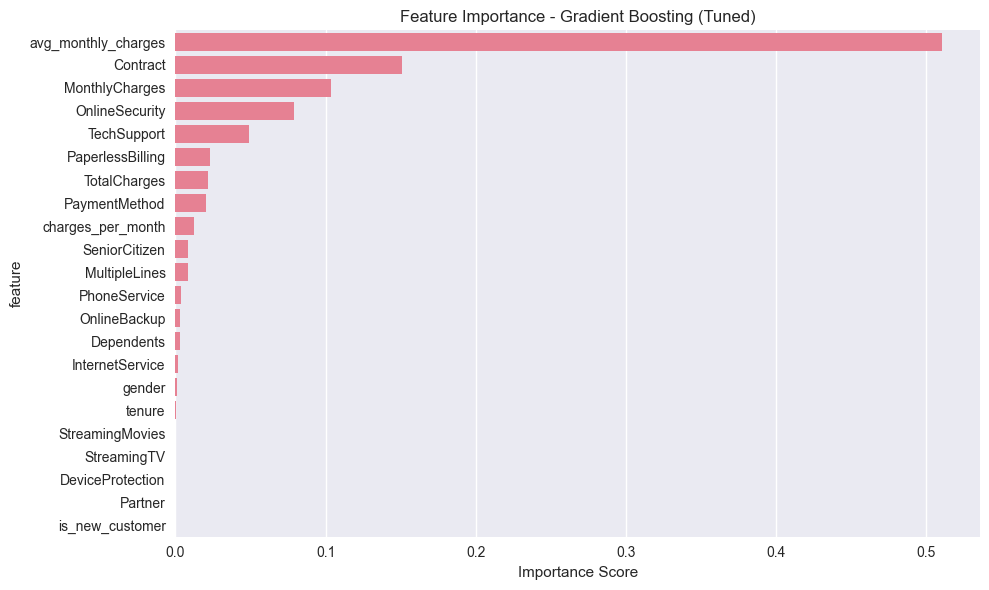

🏃 View run feature_importance_analysis at: http://127.0.0.1:5000/#/experiments/355494351460860678/runs/2ad8de65e4f24984bc12f639a94e1193
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/355494351460860678


In [34]:
# Feature importance analysis
if hasattr(best_tuned_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_tuned_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("Feature Importance:")
    print(feature_importance)

    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature')
    plt.title(f'Feature Importance - {best_model_name} (Tuned)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    # Log feature importance
    feature_importance_dict = dict(zip(feature_importance['feature'], feature_importance['importance']))
    with mlflow.start_run(run_name="feature_importance_analysis"):
        for feature, importance in feature_importance_dict.items():
            mlflow.log_metric(f"importance_{feature}", importance)

else:
    print(f"Feature importance not available for {best_model_name}")

## 6. Model Interpretation

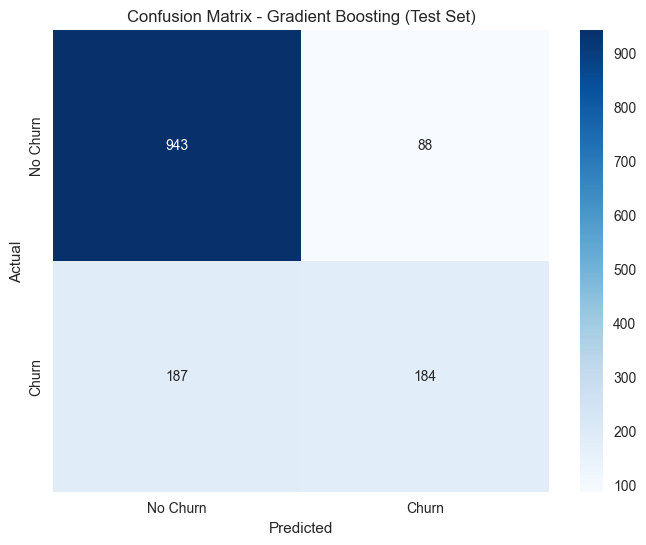


Classification Report - Gradient Boosting (Test Set):
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1031
       Churn       0.68      0.50      0.57       371

    accuracy                           0.80      1402
   macro avg       0.76      0.71      0.72      1402
weighted avg       0.79      0.80      0.79      1402



In [35]:
# Confusion matrix for best model
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name} (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print(f"\nClassification Report - {best_model_name} (Test Set):")
print(classification_report(y_test, y_pred_test_tuned, target_names=['No Churn', 'Churn']))

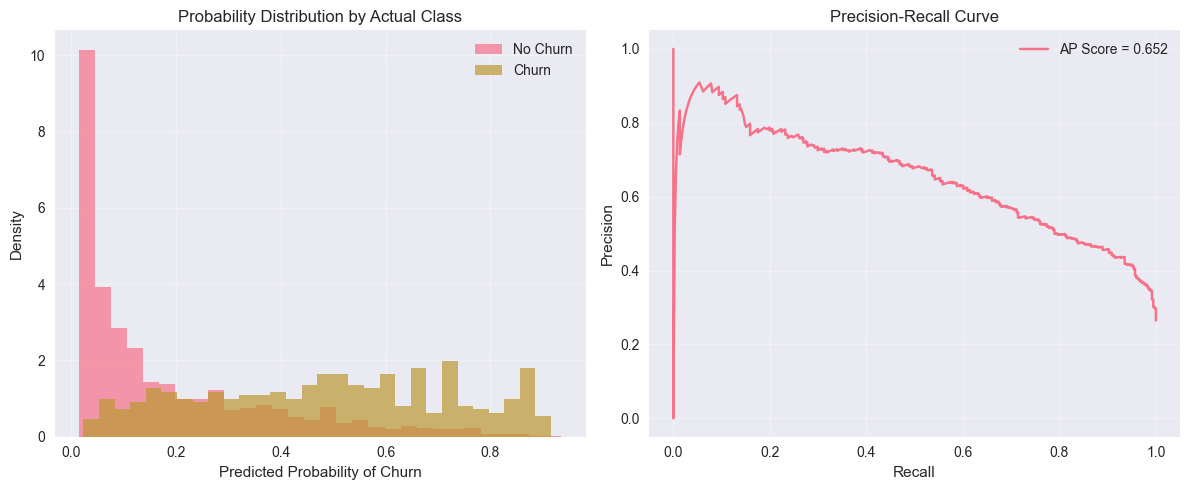

In [36]:
# Probability distribution analysis
plt.figure(figsize=(12, 5))

# Subplot 1: Probability distributions
plt.subplot(1, 2, 1)
plt.hist(y_proba_test_tuned[y_test == 0], bins=30, alpha=0.7, label='No Churn', density=True)
plt.hist(y_proba_test_tuned[y_test == 1], bins=30, alpha=0.7, label='Churn', density=True)
plt.xlabel('Predicted Probability of Churn')
plt.ylabel('Density')
plt.title('Probability Distribution by Actual Class')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_test_tuned)
avg_precision = average_precision_score(y_test, y_proba_test_tuned)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'AP Score = {avg_precision:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Validation and Cross-Validation

In [37]:
# Cross-validation analysis
from sklearn.model_selection import cross_validate

print("Performing cross-validation analysis...")

# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation
cv_results = cross_validate(best_tuned_model, X_train, y_train, 
                           cv=5, scoring=scoring, return_train_score=True)

# Create results dataframe
cv_summary = pd.DataFrame({
    'Metric': [metric.replace('test_', '').title() for metric in scoring],
    'Mean CV Score': [cv_results[f'test_{metric}'].mean() for metric in scoring],
    'Std CV Score': [cv_results[f'test_{metric}'].std() for metric in scoring],
    'Mean Train Score': [cv_results[f'train_{metric}'].mean() for metric in scoring],
    'Std Train Score': [cv_results[f'train_{metric}'].std() for metric in scoring]
    })

print("\nCross-Validation Results:")
print(cv_summary.round(4))

# Check for overfitting
cv_summary['Overfitting'] = cv_summary['Mean Train Score'] - cv_summary['Mean CV Score']
print("\nOverfitting Analysis (Train - CV):")
print(cv_summary[['Metric', 'Overfitting']].round(4))

Performing cross-validation analysis...

Cross-Validation Results:
      Metric  Mean CV Score  Std CV Score  Mean Train Score  Std Train Score
0   Accuracy         0.8025        0.0109            0.8213           0.0031
1  Precision         0.6712        0.0348            0.7155           0.0041
2     Recall         0.5029        0.0210            0.5410           0.0172
3         F1         0.5745        0.0205            0.6160           0.0116
4    Roc_Auc         0.8443        0.0134            0.8714           0.0028

Overfitting Analysis (Train - CV):
      Metric  Overfitting
0   Accuracy       0.0188
1  Precision       0.0444
2     Recall       0.0381
3         F1       0.0415
4    Roc_Auc       0.0272


## 8. Model Saving and Registration

In [38]:
# Register the best model
with mlflow.start_run(run_name="final_model_registration"):
    # Log final model with all metadata
    mlflow.log_params({
        'model_type': best_model_name,
        'features_used': feature_columns,
        'preprocessing': 'StandardScaler + Feature Engineering',
        'validation_strategy': '5-fold CV'
    })
    
    # Log final metrics
    mlflow.log_metrics({
        'final_test_accuracy': tuned_metrics['test_accuracy'],
        'final_test_auc': tuned_metrics['test_auc'],
        'final_test_f1': tuned_metrics['test_f1'],
        'cv_auc_mean': cv_results['test_roc_auc'].mean(),
        'cv_auc_std': cv_results['test_roc_auc'].std()
    })

    # Log model
    mlflow.sklearn.log_model(
        best_tuned_model, 
        name=name,
        registered_model_name="customer_churn_predictor",
        signature=signature, 
        input_example=X_val.iloc[:5]
    )
   
    # Log feature importance if available
    if hasattr(best_tuned_model, 'feature_importances_'):
        importance_dict = dict(zip(feature_columns, best_tuned_model.feature_importances_))
        mlflow.log_dict(importance_dict, "feature_importance.json")
    
    print(f"Model registered successfully!")
    print(f"Model name: customer_churn_predictor")
    print(f"Test AUC: {tuned_metrics['test_auc']:.4f}")
    print(f"Test Accuracy: {tuned_metrics['test_accuracy']:.4f}")

Registered model 'customer_churn_predictor' already exists. Creating a new version of this model...
2025/08/08 18:17:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: customer_churn_predictor, version 5


Model registered successfully!
Model name: customer_churn_predictor
Test AUC: 0.8468
Test Accuracy: 0.8039
🏃 View run final_model_registration at: http://127.0.0.1:5000/#/experiments/355494351460860678/runs/e2323943fa704898b5fb21b96f187259
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/355494351460860678


Created version '5' of model 'customer_churn_predictor'.


## 9. Model Summary and Next Steps

In [39]:
# Final model summary
print("Model Development Summary")
print("=" * 50)
print(f"Best Model: {best_model_name}")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"")
print(f"Performance Metrics (Test Set):")
print(f"Accuracy: {tuned_metrics['test_accuracy']:.4f}")
print(f"Precision: {tuned_metrics['test_precision']:.4f}")
print(f"Recall: {tuned_metrics['test_recall']:.4f}")
print(f"F1-Score: {tuned_metrics['test_f1']:.4f}")
print(f"AUC-ROC: {tuned_metrics['test_auc']:.4f}")
print(f"")
print(f"Cross-Validation AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std()*2:.4f})")

if hasattr(best_tuned_model, 'feature_importances_'):
    top_features = feature_importance.head(3)
    print(f"\nTop 3 Important Features:")
    for _, row in top_features.iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")

Model Development Summary
Best Model: Gradient Boosting
Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 1.0}

Performance Metrics (Test Set):
Accuracy: 0.8039
Precision: 0.6765
Recall: 0.4960
F1-Score: 0.5723
AUC-ROC: 0.8468

Cross-Validation AUC: 0.8443 (+/- 0.0268)

Top 3 Important Features:
  avg_monthly_charges: 0.5101
  Contract: 0.1510
  MonthlyCharges: 0.1036


In [40]:
# Save model artifacts locally for deployment
import joblib

# Save final model
joblib.dump(best_tuned_model, '../models/production/final_model.pkl')

# Save model metadata
model_metadata = {
    'model_type': best_model_name,
    'parameters': grid_search.best_params_,
    'features': feature_columns,
    'performance': tuned_metrics,
    'cv_results': {
        'mean_auc': cv_results['test_roc_auc'].mean(),
        'std_auc': cv_results['test_roc_auc'].std()
    },
    'training_date': pd.Timestamp.now().isoformat()
    }

import json
with open('../models/production/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2, default=str)

print("Model artifacts saved locally for deployment")
print("Model development completed successfully!")

Model artifacts saved locally for deployment
Model development completed successfully!
